# Notebook 1: Dataset Setup and EDA

**Dataset:** CBIS-DDSM (Curated Breast Imaging Subset of DDSM)  
**Goal:** Load metadata CSVs, verify image paths, binarise labels, and produce a cleaned linked dataset for downstream modelling.

## 1. Environment Setup
Import project config and standard libraries. Config centralises all paths, label mappings, and constants.

In [1]:
#Import config and standard libraries
import sys
sys.path.append(
    '/kaggle/input/datasets/mfjmrizvi/cbis-ddsm-project-config'
)
import config as cfg
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import json
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf

print(f"TensorFlow: {tf.__version__}")
print(f"GPUs: {tf.config.list_physical_devices('GPU')}")
print(f"\nConfig imported successfully")
print(f"  JPEG_ROOT:   {cfg.JPEG_ROOT}")
print(f"  PATCH_SIZE:  {cfg.PATCH_SIZE}")
print(f"  LABEL_MAP:   {cfg.LABEL_MAP}")
print(f"  RANDOM_SEED: {cfg.RANDOM_SEED}")

Config loaded successfully


2026-06-26 13:31:50.415300: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782480710.630021      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782480710.696100      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782480711.236028      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782480711.236072      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782480711.236075      57 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]

Config imported successfully
  JPEG_ROOT:   /kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg
  PATCH_SIZE:  224
  LABEL_MAP:   {'MALIGNANT': 1, 'BENIGN': 0, 'BENIGN_WITHOUT_CALLBACK': 0}
  RANDOM_SEED: 42


## 2. Path Verification
Confirm all dataset CSVs and the JPEG image root are accessible before loading.

In [6]:
#Verify all paths exist

print("=== PATH VERIFICATION ===")
paths = {
    'MASS_TRAIN_CSV': cfg.MASS_TRAIN_CSV,
    'MASS_TEST_CSV':  cfg.MASS_TEST_CSV,
    'CALC_TRAIN_CSV': cfg.CALC_TRAIN_CSV,
    'CALC_TEST_CSV':  cfg.CALC_TEST_CSV,
    'DICOM_INFO_CSV': cfg.DICOM_INFO_CSV,
    'JPEG_ROOT':      cfg.JPEG_ROOT,
}

all_ok = True
for name, path in paths.items():
    exists = os.path.exists(path)
    print(f"  {'✓' if exists else '✗ MISSING'} {name}")
    if not exists:
        all_ok = False

print(f"\nAll paths OK: {all_ok}")


=== PATH VERIFICATION ===
  ✓ MASS_TRAIN_CSV
  ✓ MASS_TEST_CSV
  ✓ CALC_TRAIN_CSV
  ✓ CALC_TEST_CSV
  ✓ DICOM_INFO_CSV
  ✓ JPEG_ROOT

All paths OK: True


## 3. Load Raw Metadata
CBIS-DDSM provides separate CSVs for mass and calcification cases (train/test splits).  
`dicom_info.csv` is used later to resolve image UIDs to JPEG file paths.

In [7]:
#Load all CSV files

mass_train_raw = pd.read_csv(cfg.MASS_TRAIN_CSV)
mass_test_raw  = pd.read_csv(cfg.MASS_TEST_CSV)
calc_train_raw = pd.read_csv(cfg.CALC_TRAIN_CSV)
calc_test_raw  = pd.read_csv(cfg.CALC_TEST_CSV)
dicom_info     = pd.read_csv(cfg.DICOM_INFO_CSV)

print("=== SHAPES ===")
print(f"mass_train: {mass_train_raw.shape}")
print(f"mass_test:  {mass_test_raw.shape}")
print(f"calc_train: {calc_train_raw.shape}")
print(f"calc_test:  {calc_test_raw.shape}")
print(f"dicom_info: {dicom_info.shape}")

=== SHAPES ===
mass_train: (1318, 14)
mass_test:  (378, 14)
calc_train: (1546, 14)
calc_test:  (326, 14)
dicom_info: (10237, 38)


## 4. Schema Inspection
Mass and calcification CSVs share most columns but differ in lesion-specific fields  
(`mass shape` / `mass margins` vs. `calc type` / `calc distribution`).

In [8]:
#Inspect column names

print("=== MASS TRAIN COLUMNS ===")
for i, col in enumerate(mass_train_raw.columns):
    print(f"  [{i:2d}] '{col}'")

print("\n=== CALC TRAIN COLUMNS ===")
for i, col in enumerate(calc_train_raw.columns):
    print(f"  [{i:2d}] '{col}'")

=== MASS TRAIN COLUMNS ===
  [ 0] 'patient_id'
  [ 1] 'breast_density'
  [ 2] 'left or right breast'
  [ 3] 'image view'
  [ 4] 'abnormality id'
  [ 5] 'abnormality type'
  [ 6] 'mass shape'
  [ 7] 'mass margins'
  [ 8] 'assessment'
  [ 9] 'pathology'
  [10] 'subtlety'
  [11] 'image file path'
  [12] 'cropped image file path'
  [13] 'ROI mask file path'

=== CALC TRAIN COLUMNS ===
  [ 0] 'patient_id'
  [ 1] 'breast density'
  [ 2] 'left or right breast'
  [ 3] 'image view'
  [ 4] 'abnormality id'
  [ 5] 'abnormality type'
  [ 6] 'calc type'
  [ 7] 'calc distribution'
  [ 8] 'assessment'
  [ 9] 'pathology'
  [10] 'subtlety'
  [11] 'image file path'
  [12] 'cropped image file path'
  [13] 'ROI mask file path'


## 5. Label Distribution
Three raw pathology classes: `MALIGNANT`, `BENIGN`, `BENIGN_WITHOUT_CALLBACK`.  
Both benign classes are collapsed to `0` in the binary task.

In [9]:
#Pathology label inspection

print("=== MASS TRAIN PATHOLOGY ===")
print(mass_train_raw['pathology'].value_counts())
print("Unique:", mass_train_raw['pathology'].unique())

print("\n=== MASS TEST PATHOLOGY ===")
print(mass_test_raw['pathology'].value_counts())

print("\n=== CALC TRAIN PATHOLOGY ===")
print(calc_train_raw['pathology'].value_counts())

print("\n=== CALC TEST PATHOLOGY ===")
print(calc_test_raw['pathology'].value_counts())

=== MASS TRAIN PATHOLOGY ===
pathology
MALIGNANT                  637
BENIGN                     577
BENIGN_WITHOUT_CALLBACK    104
Name: count, dtype: int64
Unique: ['MALIGNANT' 'BENIGN' 'BENIGN_WITHOUT_CALLBACK']

=== MASS TEST PATHOLOGY ===
pathology
BENIGN                     194
MALIGNANT                  147
BENIGN_WITHOUT_CALLBACK     37
Name: count, dtype: int64

=== CALC TRAIN PATHOLOGY ===
pathology
MALIGNANT                  544
BENIGN                     528
BENIGN_WITHOUT_CALLBACK    474
Name: count, dtype: int64

=== CALC TEST PATHOLOGY ===
pathology
BENIGN                     130
MALIGNANT                  129
BENIGN_WITHOUT_CALLBACK     67
Name: count, dtype: int64


## 6. Missing Value Audit
Identify nulls in lesion-descriptor columns. These are descriptive only and do not affect image loading or labels.

In [10]:
#Missing value audit

print("=== MISSING VALUES — MASS TRAIN ===")
m_missing = mass_train_raw.isnull().sum()
print(m_missing[m_missing > 0])
print(f"Total: {m_missing.sum()}")

print("\n=== MISSING VALUES — CALC TRAIN ===")
c_missing = calc_train_raw.isnull().sum()
print(c_missing[c_missing > 0])
print(f"Total: {c_missing.sum()}")

=== MISSING VALUES — MASS TRAIN ===
mass shape       4
mass margins    43
dtype: int64
Total: 47

=== MISSING VALUES — CALC TRAIN ===
calc type             20
calc distribution    376
dtype: int64
Total: 396


## 7. Label Binarisation
Map `MALIGNANT → 1` and both benign classes `→ 0` using the config's `binarise_pathology()` helper.

In [11]:
#Binarise labels using config function

mass_train = cfg.binarise_pathology(mass_train_raw)
mass_test  = cfg.binarise_pathology(mass_test_raw)
calc_train = cfg.binarise_pathology(calc_train_raw)
calc_test  = cfg.binarise_pathology(calc_test_raw)

print("=== BINARY LABEL DISTRIBUTION ===")
print("\nMass Train:")
print(mass_train['label'].value_counts())
imb = (mass_train['label'].value_counts()[0] /
       mass_train['label'].value_counts()[1])
print(f"Imbalance ratio: {imb:.2f}:1 (benign:malignant)")

print("\nMass Test:")
print(mass_test['label'].value_counts())

print("\nNull labels in mass_train:",
      mass_train['label'].isnull().sum())
print("Null labels in calc_train:",
      calc_train['label'].isnull().sum())

=== BINARY LABEL DISTRIBUTION ===

Mass Train:
label
0    681
1    637
Name: count, dtype: int64
Imbalance ratio: 1.07:1 (benign:malignant)

Mass Test:
label
0    231
1    147
Name: count, dtype: int64

Null labels in mass_train: 0
Null labels in calc_train: 0


## 8. Class Distribution Plot
Visualise label balance across all four splits. Near-balanced mass train (1.07:1) means no resampling is required.

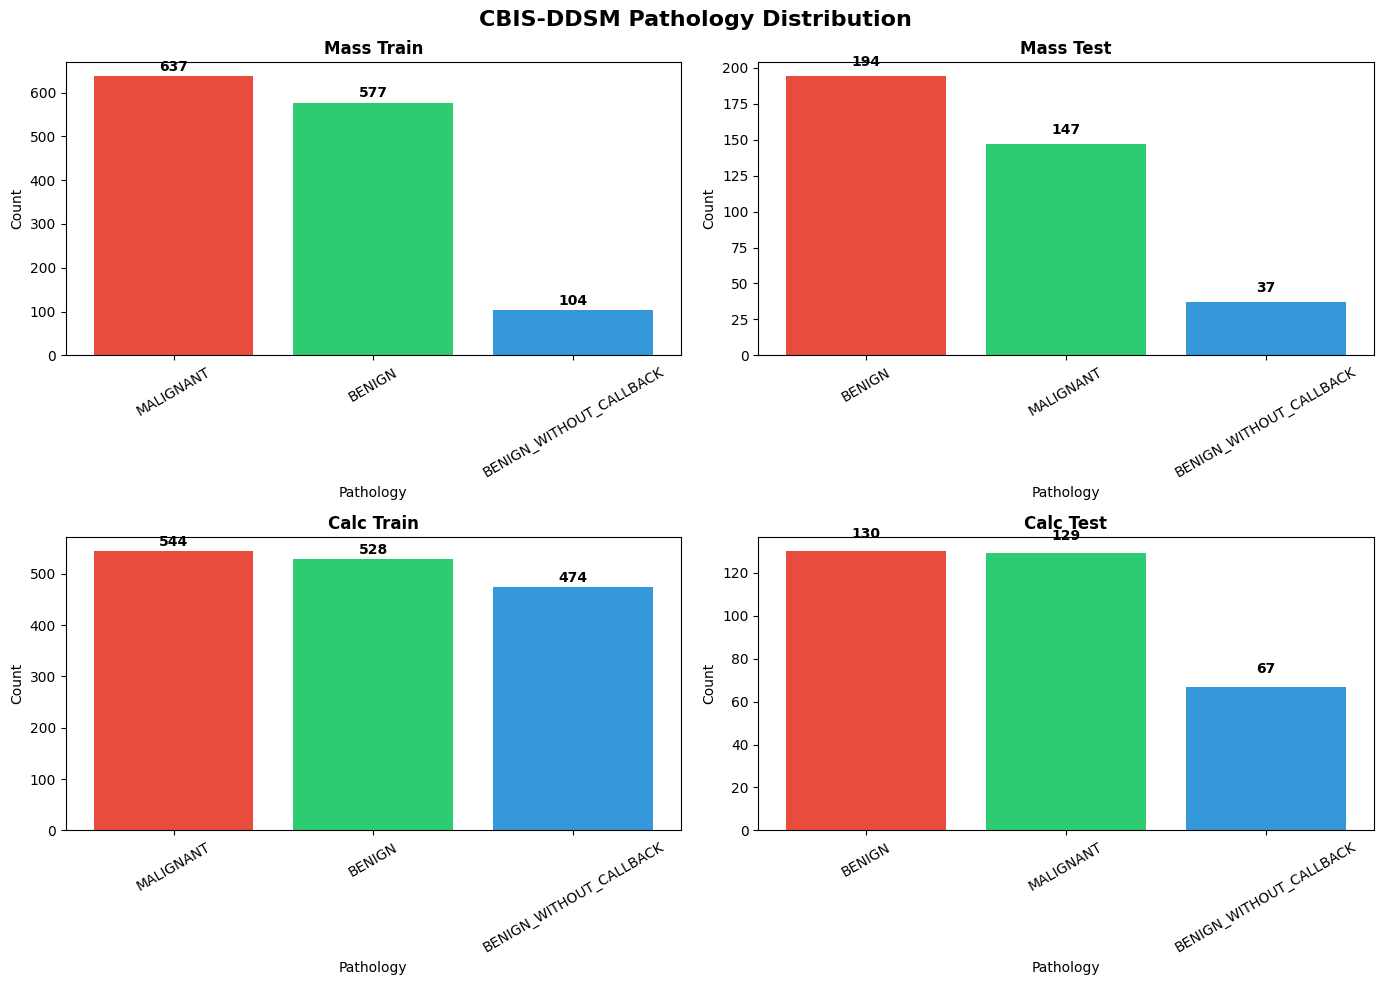

Plot saved


In [12]:
#Class distribution plot

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('CBIS-DDSM Pathology Distribution',
             fontsize=16, fontweight='bold')

datasets = [
    (mass_train, 'Mass Train',  axes[0, 0]),
    (mass_test,  'Mass Test',   axes[0, 1]),
    (calc_train, 'Calc Train',  axes[1, 0]),
    (calc_test,  'Calc Test',   axes[1, 1]),
]
colors = ['#e74c3c', '#2ecc71', '#3498db']

for df, title, ax in datasets:
    counts = df['pathology'].value_counts()
    bars = ax.bar(counts.index, counts.values,
                  color=colors[:len(counts)])
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Pathology')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)
    for bar, count in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 5,
                str(count), ha='center', va='bottom',
                fontweight='bold')

plt.tight_layout()
plt.savefig(f'{cfg.OUTPUT}/pathology_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

## 9. Build Image Path Maps
`dicom_info.csv` maps study UIDs to JPEG filenames. Separate maps are built for full mammograms and cropped ROI patches.

In [13]:
#Build image path maps using config functions

full_path_map = cfg.build_path_map(
    dicom_info, 'full mammogram images', cfg.JPEG_ROOT
)
cropped_path_map = cfg.build_path_map(
    dicom_info, 'cropped images', cfg.JPEG_ROOT
)

print(f"Full mammogram path map:  {len(full_path_map)} entries")
print(f"Cropped image path map:   {len(cropped_path_map)} entries")

# Verify one entry from each
if full_path_map:
    uid = list(full_path_map.keys())[0]
    print(f"\nSample full path exists: "
          f"{os.path.exists(full_path_map[uid])}")

if cropped_path_map:
    uid = list(cropped_path_map.keys())[0]
    print(f"Sample cropped path exists: "
          f"{os.path.exists(cropped_path_map[uid])}")

Full mammogram path map:  2857 entries
Cropped image path map:   3567 entries

Sample full path exists: True
Sample cropped path exists: True


## 10. Link Image Paths to Metadata Rows
Resolve the `image file path` and `cropped image file path` columns in the mass CSVs to absolute JPEG paths on disk.

In [15]:
#Link full image paths to mass CSV rows

full_paths_train = cfg.link_column_to_paths(
    mass_train, 'image file path', full_path_map
)
full_paths_test = cfg.link_column_to_paths(
    mass_test, 'image file path', full_path_map
)

mass_train['full_image_path'] = full_paths_train
mass_test['full_image_path']  = full_paths_test

train_linked = mass_train['full_image_path'].notna().sum()
test_linked  = mass_test['full_image_path'].notna().sum()

print(f"Full images linked (train): {train_linked}/{len(mass_train)}")
print(f"Full images linked (test):  {test_linked}/{len(mass_test)}")

Full images linked (train): 1318/1318
Full images linked (test):  378/378


In [16]:
#Link cropped image paths to mass CSV rows

cropped_paths_train = cfg.link_column_to_paths(
    mass_train, 'cropped image file path', cropped_path_map
)
cropped_paths_test = cfg.link_column_to_paths(
    mass_test, 'cropped image file path', cropped_path_map
)

mass_train['cropped_image_path'] = cropped_paths_train
mass_test['cropped_image_path']  = cropped_paths_test

train_cropped = mass_train['cropped_image_path'].notna().sum()
test_cropped  = mass_test['cropped_image_path'].notna().sum()

print(f"Cropped images linked (train): {train_cropped}/{len(mass_train)}")
print(f"Cropped images linked (test):  {test_cropped}/{len(mass_test)}")

# Verify file existence
sample = mass_train[mass_train['cropped_image_path'].notna()].iloc[0]
print(f"\nSample cropped path: {sample['cropped_image_path']}")
print(f"File exists: {os.path.exists(sample['cropped_image_path'])}")

Cropped images linked (train): 1318/1318
Cropped images linked (test):  378/378

Sample cropped path: /kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.296736403313792599626368780122205399650/2-249.jpg
File exists: True


## 11. Visual Sanity Check
Display one full and one cropped example for each class to confirm correct path linkage and image readability.

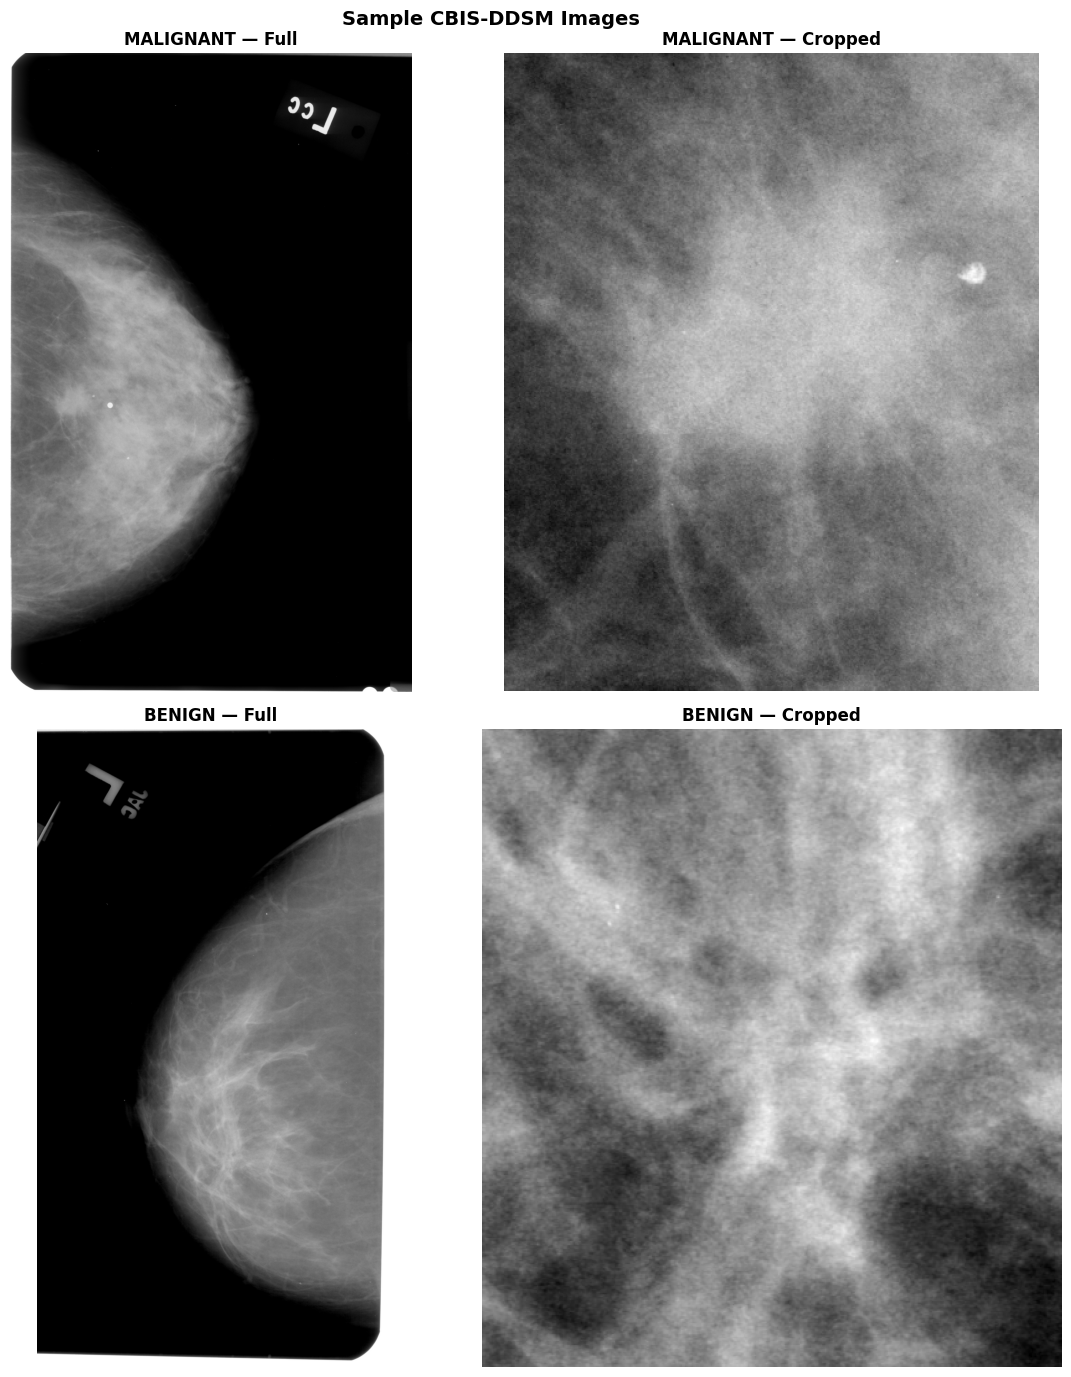

Sample images saved


In [17]:
#Display sample images

fig, axes = plt.subplots(2, 2, figsize=(12, 14))
fig.suptitle('Sample CBIS-DDSM Images', fontsize=14, fontweight='bold')

samples = [
    (mass_train[mass_train['label']==1].iloc[0],
     'MALIGNANT — Full',    'full_image_path',    axes[0,0]),
    (mass_train[mass_train['label']==1].iloc[0],
     'MALIGNANT — Cropped', 'cropped_image_path', axes[0,1]),
    (mass_train[mass_train['label']==0].iloc[0],
     'BENIGN — Full',       'full_image_path',    axes[1,0]),
    (mass_train[mass_train['label']==0].iloc[0],
     'BENIGN — Cropped',    'cropped_image_path', axes[1,1]),
]

for sample, title, col, ax in samples:
    path = sample[col]
    if pd.notna(path) and os.path.exists(path):
        img = mpimg.imread(path)
        ax.imshow(img, cmap='gray')
        ax.set_title(title, fontweight='bold')
    else:
        ax.text(0.5, 0.5, 'Image not found',
                ha='center', va='center')
        ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.savefig(f'{cfg.OUTPUT}/sample_images.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Sample images saved")

## 12. Drop Unlinked Rows & Finalise
Remove any rows where either image path is missing. All 1318 train and 378 test rows survive, confirming complete linkage.

In [18]:
#Drop unlinked rows and verify final state

mass_train_clean = mass_train[
    mass_train['full_image_path'].notna() &
    mass_train['cropped_image_path'].notna()
].reset_index(drop=True)

mass_test_clean = mass_test[
    mass_test['full_image_path'].notna() &
    mass_test['cropped_image_path'].notna()
].reset_index(drop=True)

print(f"mass_train after cleaning: {len(mass_train_clean)}")
print(f"mass_test after cleaning:  {len(mass_test_clean)}")

print(f"\nFinal label distribution (train):")
print(mass_train_clean['label'].value_counts())

print(f"\nFinal columns:")
print(mass_train_clean.columns.tolist())

mass_train after cleaning: 1318
mass_test after cleaning:  378

Final label distribution (train):
label
0    681
1    637
Name: count, dtype: int64

Final columns:
['patient_id', 'breast_density', 'left or right breast', 'image view', 'abnormality id', 'abnormality type', 'mass shape', 'mass margins', 'assessment', 'pathology', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path', 'label', 'full_image_path', 'cropped_image_path']


## 13. Patient-Level Audit
In MIL, each patient maps to one bag. Patients with multiple lesions
need a consistent bag-level label strategy

In [19]:
# Patient-level abnormality audit
obs_per_patient = mass_train_clean.groupby('patient_id').size()
print(f"Max abnormalities per patient: {obs_per_patient.max()}")
print(f"Patients with multiple lesions: {(obs_per_patient > 1).sum()}")
print(f"Total unique patients: {mass_train_clean['patient_id'].nunique()}")

Max abnormalities per patient: 14
Patients with multiple lesions: 495
Total unique patients: 691


71% of patients have multiple lesion rows. In this pipeline, each row 
is treated as an independent bag, so mixed-pathology patients 
produce separate correctly-labelled bags and not a labelling conflict. 
Patient grouping is used only to enforce a leak-free train/val split.

## 14. Save Outputs
Export the cleaned, path-linked CSVs and an EDA summary JSON for use in subsequent notebooks.

In [15]:
#Save linked CSVs as notebook outputs

mass_train_clean.to_csv(
    f'{cfg.OUTPUT}/mass_train_linked.csv', index=False)
mass_test_clean.to_csv(
    f'{cfg.OUTPUT}/mass_test_linked.csv',  index=False)

print("Saved:")
print(f"  {cfg.OUTPUT}/mass_train_linked.csv"
      f" — {len(mass_train_clean)} rows")
print(f"  {cfg.OUTPUT}/mass_test_linked.csv"
      f" — {len(mass_test_clean)} rows")

Saved:
  /kaggle/working/mass_train_linked.csv — 1318 rows
  /kaggle/working/mass_test_linked.csv — 378 rows


In [18]:
#Save EDA summary JSON

summary = {
    'dataset':       'CBIS-DDSM (awsaf49 Kaggle)',
    'labels_source': 'Official TCIA download',
    'scope':         'Mass cases only (prototype phase)',
    'label_mapping': cfg.LABEL_MAP,
    'mass_train': {
        'total_rows':        len(mass_train_clean),
        'label_0_benign':    int(
            mass_train_clean['label'].value_counts()[0]),
        'label_1_malignant': int(
            mass_train_clean['label'].value_counts()[1]),
        'full_linked':       int(
            mass_train_clean['full_image_path'].notna().sum()),
        'cropped_linked':    int(
            mass_train_clean['cropped_image_path'].notna().sum()),
    },
    'mass_test': {
        'total_rows':        len(mass_test_clean),
        'label_0_benign':    int(
            mass_test_clean['label'].value_counts()[0]),
        'label_1_malignant': int(
            mass_test_clean['label'].value_counts()[1]),
    },
    'missing_values': {
        'mass_shape':   4,
        'mass_margins': 43,
        'impact':       'Low — descriptive columns only'
    }
}

with open(f'{cfg.OUTPUT}/eda_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("EDA summary saved")
print(json.dumps(summary, indent=2))

EDA summary saved
{
  "dataset": "CBIS-DDSM (awsaf49 Kaggle)",
  "labels_source": "Official TCIA download",
  "scope": "Mass cases only (prototype phase)",
  "label_mapping": {
    "MALIGNANT": 1,
    "BENIGN": 0,
    "BENIGN_WITHOUT_CALLBACK": 0
  },
  "mass_train": {
    "total_rows": 1318,
    "label_0_benign": 681,
    "label_1_malignant": 637,
    "full_linked": 1318,
    "cropped_linked": 1318
  },
  "mass_test": {
    "total_rows": 378,
    "label_0_benign": 231,
    "label_1_malignant": 147
  },
  "missing_values": {
    "mass_shape": 4,
    "mass_margins": 43,
    "impact": "Low \u2014 descriptive columns only"
  }
}
